# Milestone 3: EDA, Planning, and Setting Goals

[Due 4/18: Instructions](https://edstem.org/us/courses/74185/lessons/130679/slides/736236)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import utils.preprocessing as pp
import utils.visualization as viz


## Data Description

Provide any missing information from Milestone 2 based on the feedback you received from your grader. 

In [36]:
satCat_current = pd.DataFrame(pp.loadUnprocessedSatCat_current("../data/satcat.zip")).set_index("NORAD_CAT_ID")
satCat_decayed = pd.DataFrame(pp.loadUnprocessedSatCat_decayed("../data/satcat.zip")).set_index("NORAD_CAT_ID")
snapshot_states = pp.loadSeveralYearsOfUnprocessedStates(["../data/snapshots_2023.zip","../data/snapshots_2024_p1.zip","../data/snapshots_2024_p2.zip","../data/snapshots_2025.zip"])
aggregatedData, uncataloged_states, nDuplicatesFound = pp.deduplicateAndMergeDataSources(snapshot_states, satCat_current, satCat_decayed)

df = pd.DataFrame(aggregatedData)
df.shape

(1034009, 20)

In [37]:
# remove unknown
df = df[df['TYPE'] != 'UNKNOWN']
df.shape

(1011052, 20)

## Summary of the Data

Provide the shape of the data, data types, and descriptive statistics such as mean, max, and dtypes. Additionally, provide a summary of the features of the data, including histograms, correlation plots, and clustering plots as appropriate. 

In [ ]:
df.head(2)

,NUMBER,NAME,TYPE,RCS,IS_CURRENT,REGIME,EPOCH,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,COUNTRY,LINE1,LINE2
0,11,VANGUARD 2,PAYLOAD,MEDIUM,1,LEO,23227.529469,32.8786,39.4077,0.146176,291.2012,53.8788,11.872714,8116.494528,2924.83529,551.953765,0.000004,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,12,VANGUARD R/B,ROCKET BODY,MEDIUM,1,LEO,23227.463430,32.8971,270.9551,0.165991,26.7664,340.9673,11.457434,8311.452812,3312.97502,553.730604,0.000006,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


In [39]:
response = 'TYPE'
X_exclude = ['NUMBER', 'NAME','RCS', 'IS_CURRENT', 'REGIME', 'EPOCH', 'COUNTRY', 'LINE1', 'LINE2']
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_ANOM', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER']

In [40]:
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df[X_numerical]), columns=X_numerical)
df_scaled = pd.concat([df[response],df_scaled,   df[X_exclude]], axis=1)
df_scaled.head(2)


,TYPE,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,NUMBER,NAME,RCS,IS_CURRENT,REGIME,EPOCH,COUNTRY,LINE1,LINE2
0,PAYLOAD,-1.196979,-1.313405,0.685616,1.243249,-1.344251,-0.153392,-0.274948,-0.208660,-0.323569,-0.032034,11,VANGUARD 2,MEDIUM,1.0,LEO,23227.529469,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,ROCKET BODY,-1.196343,0.862265,0.819142,-1.424497,1.452507,-0.246231,-0.255350,-0.176047,-0.323377,-0.031479,12,VANGUARD R/B,MEDIUM,1.0,LEO,23227.463430,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


## Data Analysis

Identify patterns, trends, and outliers in the data. Additionally, explore the relationships between variables and identify any potential confounding variables that may impact the analysis.

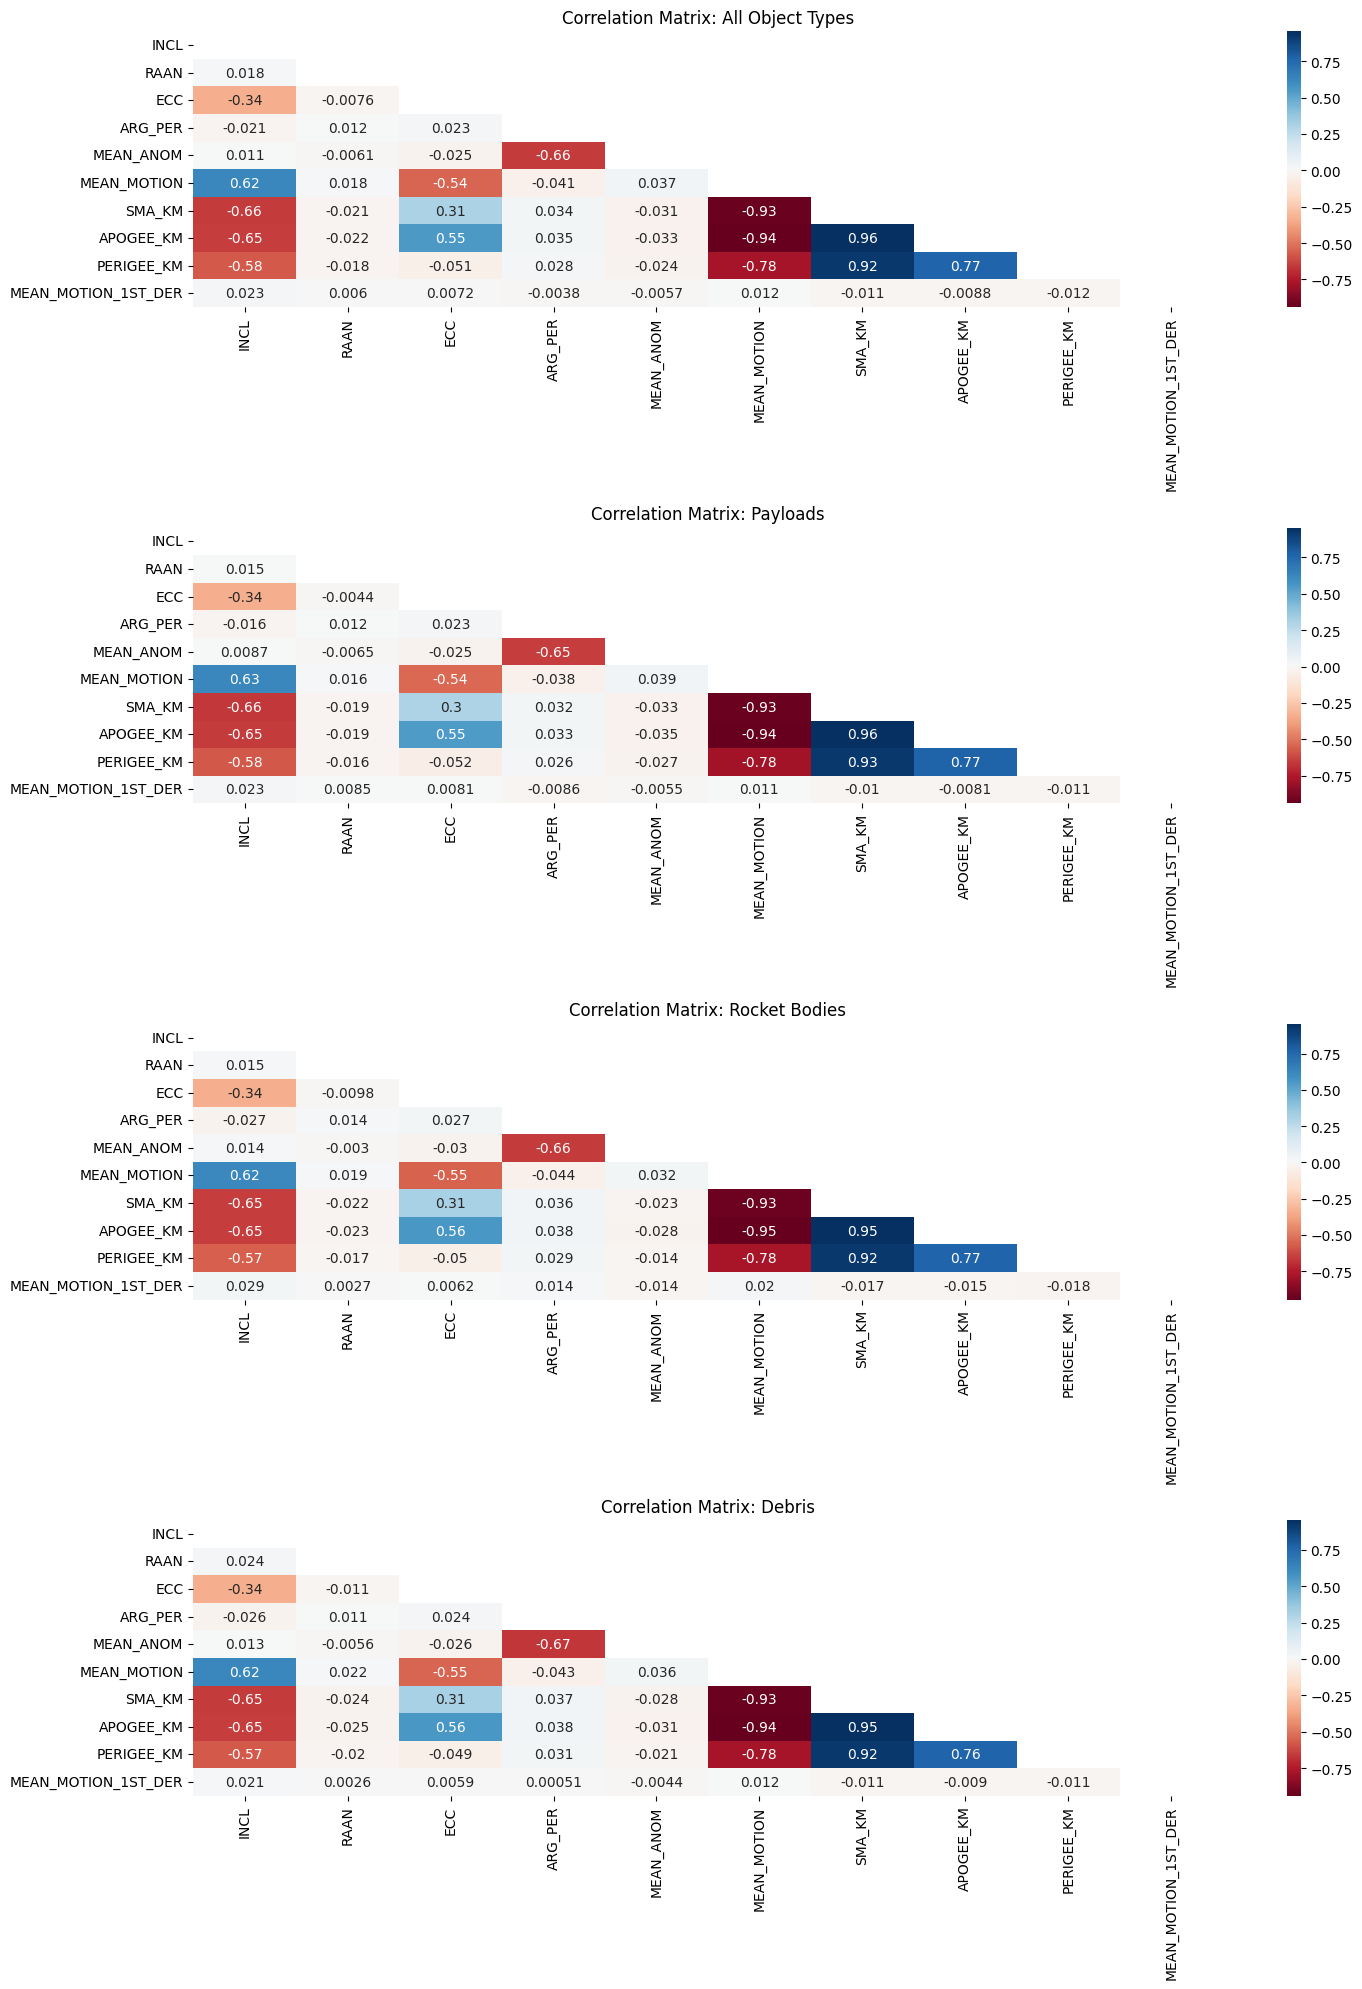

In [41]:
df_to_use = df_scaled

df_payload = df_to_use[df_to_use['TYPE']=="PAYLOAD"]
df_rb = df_to_use[df_to_use['TYPE']=="ROCKET BODY"]
df_db = df_to_use[df_to_use['TYPE']=="DEBRIS"]

corr_payload = df_payload[X_numerical].corr()
corr_rb = df_rb[X_numerical].corr()  
corr_db = df_db[X_numerical].corr() 
corr = df_to_use[X_numerical].corr()

fig, ax = plt.subplots(4,1, figsize=(15, 20))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap='RdBu', ax=ax[0], annot=True)
ax[0].set_title('Correlation Matrix: All Object Types')
sns.heatmap(corr_payload, mask=np.triu(np.ones_like(corr_payload, dtype=bool)), cmap='RdBu', ax=ax[1], annot=True)
ax[1].set_title('Correlation Matrix: Payloads')
sns.heatmap(corr_rb, mask=np.triu(np.ones_like(corr_rb, dtype=bool)), cmap='RdBu', ax=ax[2], annot=True)
ax[2].set_title('Correlation Matrix: Rocket Bodies')
sns.heatmap(corr_db, mask= np.triu(np.ones_like(corr_db, dtype=bool)), cmap='RdBu', ax=ax[3], annot=True)
ax[3].set_title('Correlation Matrix: Debris')
plt.tight_layout()
plt.show()

## Meaningful Insights

Based on your analysis of the data, provide meaningful insights. Meaningful insights are those that connect back to your problem and are relevant to your specific context. Any insights should be well-supported by the data, provide actionable recommendations, and have a brief justification for why or how it’s important to the project. 

## Clean and Labeled Visualizations

 Visualizations are important components of EDA and should be clean, labeled, and well-presented. You need to ensure that your visualizations are easy to understand and can be included in their final presentation slides or report. Anyone that reads your EDA should be able to understand what is depicted in the plots just by looking at them. Viz's that are not labeled correct will result in a loss of pts. 

## Summary of findings

Summarize your findings in a clear and concise manner. This can be achieved through the use of visualizations and captions that highlight the most important insights gained through the analysis.

## (Revised) Project Question

Based on the insights gained through EDA, you should develop a clear project/research question that will guide your analysis. This question should be well-defined, specific to the problem at hand, and an improvement from the initial project proposal.